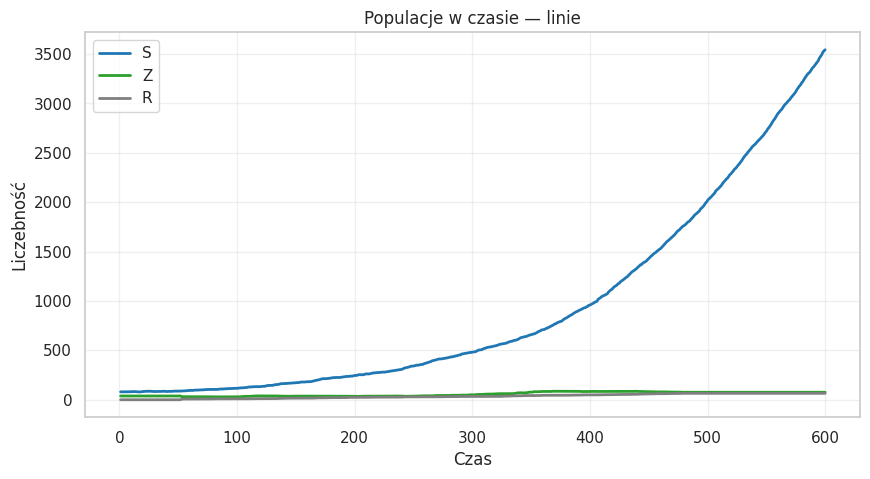

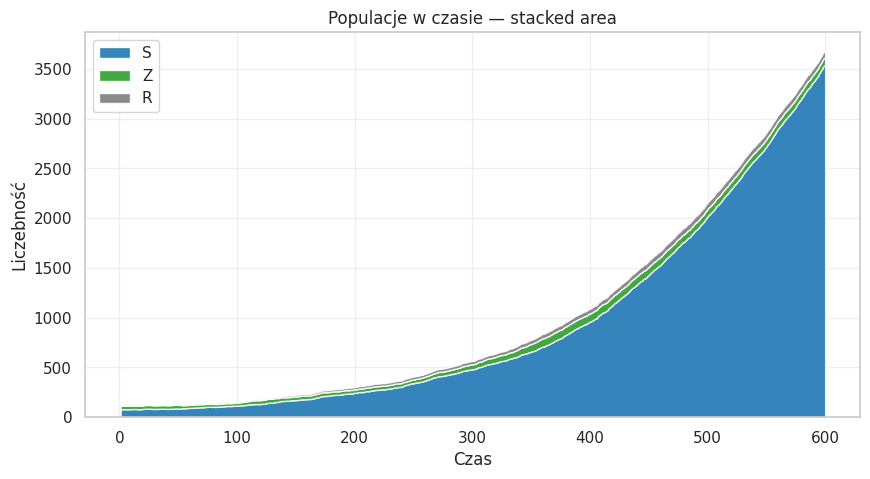

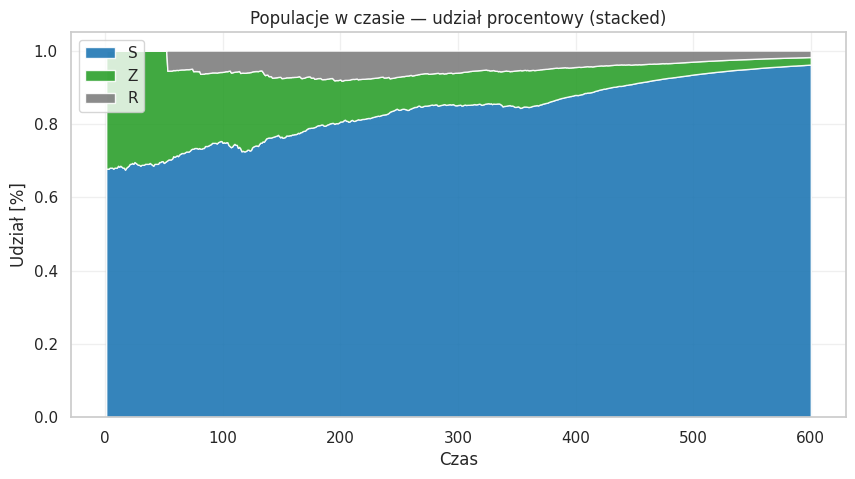

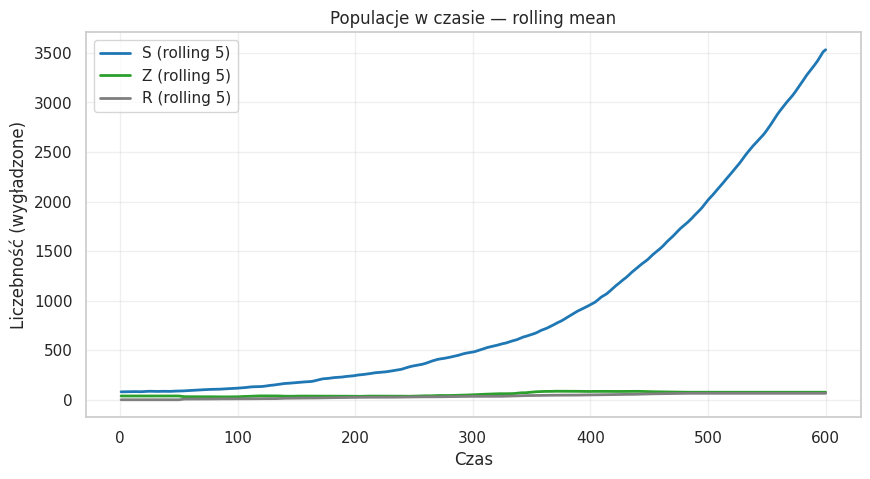

('fig/populations_line.png',
 'fig/populations_stacked.png',
 'fig/populations_percent.png',
 'fig/populations_rolling.png')

In [4]:
# Wizualizacja populacji z CSV: linie, obszary, procenty, wygładzanie
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Ścieżka do CSV — obsłuż dwie lokalizacje
candidates = [
    os.path.join('notebooks', 'populations.csv'),  # gdy CWD=repo root
    os.path.join(os.getcwd(), 'populations.csv'),  # gdy CWD=notebooks/
]
csv_path = None
for p in candidates:
    if os.path.exists(p):
        csv_path = p
        break
if csv_path is None:
    raise FileNotFoundError(f"Nie znaleziono populations.csv w: {candidates}")

# Wczytanie danych i standaryzacja kolumn
df = pd.read_csv(csv_path)
cols = {c.lower(): c for c in df.columns}
time_col = cols.get('time', df.columns[0])
S_col = cols.get('s', 'S')
Z_col = cols.get('z', 'Z')
R_col = cols.get('r', 'R')

plot_df = pd.DataFrame({
    'time': df[time_col].values,
    'S': df[S_col].values,
    'Z': df[Z_col].values,
    'R': df[R_col].values,
})

# Paleta zgodna z aplikacją
palette = {
    'S': '#1f77b4',  # Blue (Human)
    'Z': '#2ca02c',  # Green (Zombie)
    'R': '#7f7f7f',  # Gray (Removed)
}

# 1) Wykres liniowy
fig, ax = plt.subplots(figsize=(10, 5))
for col in ['S', 'Z', 'R']:
    ax.plot(plot_df['time'], plot_df[col], label=col, color=palette[col], linewidth=2)
ax.set_xlabel('Czas')
ax.set_ylabel('Liczebność')
ax.set_title('Populacje w czasie — linie')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
plt.close(fig)

# 2) Wykres obszarowy (stacked area)
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(
    plot_df['time'],
    plot_df['S'], plot_df['Z'], plot_df['R'],
    labels=['S','Z','R'], colors=[palette['S'], palette['Z'], palette['R']], alpha=0.9
)
ax.set_xlabel('Czas')
ax.set_ylabel('Liczebność')
ax.set_title('Populacje w czasie — stacked area')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()
plt.close(fig)

# 3) Udział procentowy (znormalizowany stacked area)
normalized = plot_df[['S','Z','R']].div(plot_df[['S','Z','R']].sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(
    plot_df['time'],
    normalized['S'], normalized['Z'], normalized['R'],
    labels=['S','Z','R'], colors=[palette['S'], palette['Z'], palette['R']], alpha=0.9
)
ax.set_xlabel('Czas')
ax.set_ylabel('Udział [%]')
ax.set_title('Populacje w czasie — udział procentowy (stacked)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()
plt.close(fig)

# 4) Wersja wygładzona (rolling mean)
win = 5
smoothed = plot_df[['S','Z','R']].rolling(window=win, min_periods=1, center=True).mean()
fig, ax = plt.subplots(figsize=(10, 5))
for col in ['S','Z','R']:
    ax.plot(plot_df['time'], smoothed[col], label=f"{col} (rolling {win})", color=palette[col], linewidth=2)
ax.set_xlabel('Czas')
ax.set_ylabel('Liczebność (wygładzone)')
ax.set_title('Populacje w czasie — rolling mean')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
plt.close(fig)

# 5) Zapis figur do katalogu fig/
os.makedirs('fig', exist_ok=True)

# Line plot save
fig, ax = plt.subplots(figsize=(10, 5))
for col in ['S', 'Z', 'R']:
    ax.plot(plot_df['time'], plot_df[col], label=col, color=palette[col], linewidth=2)
ax.set_xlabel('Czas'); ax.set_ylabel('Liczebność'); ax.set_title('Populacje — linie'); ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path1 = os.path.join('fig', 'populations_line.png')
fig.savefig(fig_path1, dpi=160)
plt.close(fig)

# Stacked area save
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(plot_df['time'], plot_df['S'], plot_df['Z'], plot_df['R'], labels=['S','Z','R'], colors=[palette['S'], palette['Z'], palette['R']], alpha=0.9)
ax.set_xlabel('Czas'); ax.set_ylabel('Liczebność'); ax.set_title('Populacje — stacked area'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path2 = os.path.join('fig', 'populations_stacked.png')
fig.savefig(fig_path2, dpi=160)
plt.close(fig)

# Normalized stacked save
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(plot_df['time'], normalized['S'], normalized['Z'], normalized['R'], labels=['S','Z','R'], colors=[palette['S'], palette['Z'], palette['R']], alpha=0.9)
ax.set_xlabel('Czas'); ax.set_ylabel('Udział [%]'); ax.set_title('Populacje — udział procentowy'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path3 = os.path.join('fig', 'populations_percent.png')
fig.savefig(fig_path3, dpi=160)
plt.close(fig)

# Rolling mean save
fig, ax = plt.subplots(figsize=(10, 5))
for col in ['S','Z','R']:
    ax.plot(plot_df['time'], smoothed[col], label=f"{col} (rolling {win})", color=palette[col], linewidth=2)
ax.set_xlabel('Czas'); ax.set_ylabel('Liczebność (wygładzone)'); ax.set_title('Populacje — rolling mean'); ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path4 = os.path.join('fig', 'populations_rolling.png')
fig.savefig(fig_path4, dpi=160)
plt.close(fig)

(fig_path1, fig_path2, fig_path3, fig_path4)